### Analysis of an E-commerce Dataset

We have been provided with a combined e-commerce dataset. In this dataset, each user has the ability to post a rating and review for the products they purchased. Additionally, other users can evaluate the initial rating and review by expressing their trust or distrust.

This dataset includes a wealth of information for each user. Details such as their profile, ID, gender, city of birth, product ratings (on a scale of 1-5), reviews, and the prices of the products they purchased are all included. Moreover, for each product rating, we have information about the product name, ID, price, and category, the rating score, the timestamp of the rating and review, and the average helpfulness of the rating given by others (on a scale of 1-5).

The dataset is from several data sources, and we have merged all the data into a single CSV file named 'A Combined E-commerce Dataset.csv'. The structure of this dataset is represented in the header shown below.

| userId | gender | rating | review| item | category | helpfulness | timestamp | item_id | item_price | user_city|

    | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |  ---- |  ---- |  
    
#### Description of Fields

* __userId__ - the user's id
* __gender__ - the user's gender
* __rating__ - the user's rating towards the item
* __review__ - the user's review towards the item
* __item__ - the item's name
* __category__ - the category of the item
* __helpfulness__ - the average helpfulness of this rating
* __timestamp__ - the timestamp when the rating is created
* __item_id__ - the item's id
* __item_price__ - the item's price
* __user_city__ - the city of user's birth

Note that, a user may rate multiple items and an item may receive ratings and reviews from multiple users. The "helpfulness" is an average value based on all the helpfulness values given by others.

There are four questions to explore with the data as shown below.



<img src="Fig1 The Combined E Commerce Dataset.png" align="left" width="400"/>
(You can find the data relation diagram on iLearn - Portfolio Part 1 resources - Fig1)


In [31]:
your_name = "Abhaypal Singh"

In [32]:
your_student_id = "47717653"

In [33]:
#library importation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

 #### Q1. Remove missing data

Please remove the following records in the csv file:

 * gender/rating/helpfulness is missing
 * review is 'none'

__Display the DataFrame, counting number of Null values in each column, and print the length of the data__ before and after removing the missing data.  

In [34]:
#presenting the dataframe
df = pd.read_csv('The E-commerce Dataset.csv')
df

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4051,12807,Great job for what it is!,eBay,5.0,2.0,F,Online Stores & Services,88,149.00,39
1,4052,122899,Free Access Worth your Time,NetZero,5.0,0.0,F,Online Stores & Services,46,53.00,39
2,33,12700,AOL..I love you!!!!!!!!!!!!,AOL (America Online),5.0,4.0,F,Online Stores & Services,0,145.84,31
3,33,21000,EBAY!!! I LOVE YOU!!!! :-)*,eBay,5.0,4.0,F,Online Stores & Services,88,149.00,31
4,33,22300,Blair Witch...Oh Come On.......,Blair Witch Project,1.0,4.0,F,Movies,12,44.00,31
...,...,...,...,...,...,...,...,...,...,...,...
19995,10805,50600,The Upper Class Fast Food,Wendy's,2.0,3.0,F,Restaurants & Gourmet,84,69.00,18
19996,10806,82201,What more can you ask for????,Olive Garden,4.0,0.0,M,Restaurants & Gourmet,49,32.00,28
19997,10806,82201,Excellent steak for a good price,Outback Steakhouse,4.0,3.0,M,Restaurants & Gourmet,50,25.00,28
19998,10807,31504,Different story world,J. K. Rowling - Harry Potter and the Sorcerer'...,4.0,0.0,M,Books,36,96.00,27


In [35]:
#counting the null values
nullcount = df.isna().sum()
nullcount


userId          0
timestamp       0
review          0
item            0
rating         17
helpfulness    22
gender         27
category        0
item_id         0
item_price      0
user_city       0
dtype: int64

In [36]:
#display the number of lines before we remove values
data_length = len(df)
print("Length of data before:",data_length)


Length of data before: 20000


In [37]:
#remove rows where gender, rating, helpfulness is missing
df = df.dropna()
#remove rows where reviews are'none'
df = df[df['review'].str.lower() != 'none']

In [38]:
#print number of lines after removing data
data_length = len(df)
print("Length of data after:",data_length)


Length of data after: 19916


#### Q2. Descriptive statistics

With the cleaned data in Q1, please provide the data summarization as below:

* Q2.1 total number of unique users, unique reviews, unique items, and unique categories
* Q2.2 descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records
* Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders
* Q2.4 descriptive statistics, e.g., mean, std, max, min of the number of ratings that received by each items


In [51]:
#2.1 total number of unique users
df['userId'].unique().size
print('the total number of unique users are:',df['userId'].unique().size)

the total number of unique users are: 8562


In [52]:
#2.1 total number of unique reviews
print('the total number of unique reviews are:',df['review'].unique().size)

the total number of unique reviews are: 19459


In [53]:
#2.1 the total number of unique items
print('the total number of unique item are:',df['item'].unique().size)

the total number of unique item are: 89


In [54]:
#2.1 total number of unique categories
print('the total number of unique categories are:',df['category'].unique().size)

the total number of unique categories are: 9


In [ ]:
#Therefore, the total number of unique users are: 8562. the total number of unique reviews are: 19459
#the total number of unique item are: 89. the total number of unique categories are: 9

In [40]:
#2.2 descriptive statistics (ratings)
df['rating'].describe()

count    19916.000000
mean         3.701798
std          1.404451
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

In [41]:
#2.3 descriptive statistics (gender)
gender_num = df.groupby(['gender'])['item'].count().reset_index(name='count')
gender_num['count'].describe()

count        2.000000
mean      9958.000000
std        233.345238
min       9793.000000
25%       9875.500000
50%       9958.000000
75%      10040.500000
max      10123.000000
Name: count, dtype: float64

In [42]:
#2.4 descriptive statistics (each item)
temp_df = df.groupby(['item'])
ratings_num = temp_df['rating'].count()
ratings_num_df = ratings_num.reset_index(name='num_ratings')
ratings_num_df.head()
ratings_num_df['num_ratings'].describe()

count     89.000000
mean     223.775281
std      116.418988
min      139.000000
25%      162.000000
50%      187.000000
75%      245.000000
max      939.000000
Name: num_ratings, dtype: float64

#### Q3. Plotting and Analysis

Please try to explore the correlation between gender/helpfulness/category and ratings; for instance, do female/male users tend to provide higher ratings than male/female users? Hint: you may use the boxplot function to plot figures for comparison (___Challenge___)
    
You may need to select the most suitable graphic forms for ease of presentation. Most importantly, for each figure or subfigure, please summarise ___what each plot shows___ (i.e. observations and explanations). Finally, you may need to provide an overall summary of the data.

<Figure size 800x600 with 0 Axes>

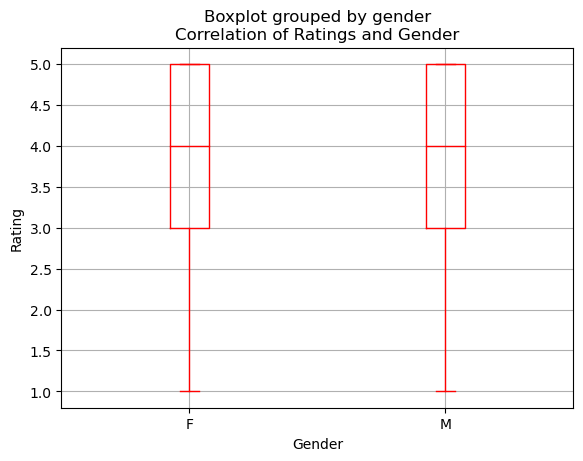

In [43]:
#box plot for gender and ratings
plt.figure(figsize=(8, 6))
df.boxplot(column='rating', by='gender', color='red')
plt.title('Correlation of Ratings and Gender')
plt.xlabel('Gender')
plt.ylabel('Rating')
plt.show()


<Figure size 800x600 with 0 Axes>

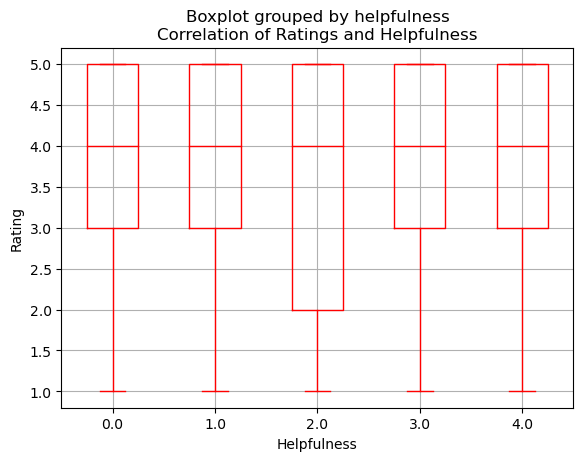

In [44]:
#box plot for helpfulness and ratings
plt.figure(figsize=(8, 6))
df.boxplot(column='rating', by='helpfulness', color='red')
plt.title('Correlation of Ratings and Helpfulness')
plt.xlabel('Helpfulness')
plt.ylabel('Rating')
plt.show()

<Figure size 800x600 with 0 Axes>

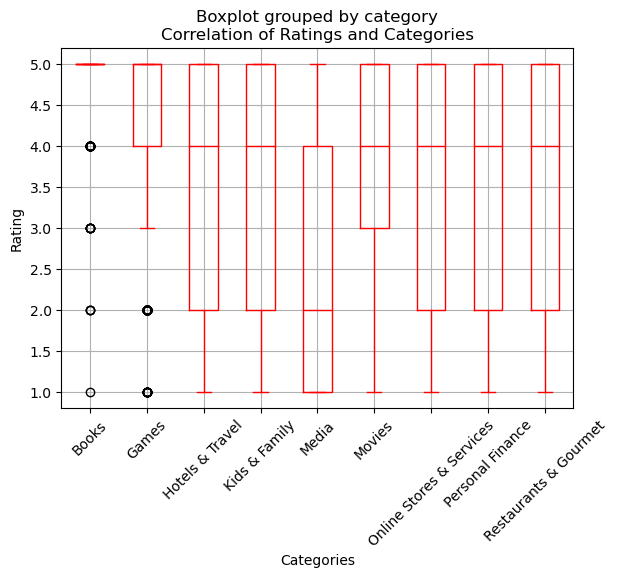

In [45]:
#box plot for ratings and categories
plt.figure(figsize=(8, 6))
df.boxplot(column='rating', by='category', rot=45, color='red')
plt.title('Correlation of Ratings and Categories')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.show()

In [46]:
#ANALYSIS

#Overall the rating distribution in the first boxplot shows that there is little to no difference with regard to rating results. 
#In the second boxplot, it is seen that users give lower ratings to the average helpfulness score of 2.
#The distribution in the third boxplot displays lower ratings in the media category, as well as a lower median and q3 score.

#### Q4. Detect and remove outliers

We may define outlier users, reviews and items with three rules (if a record meets one of the rules, it is regarded as an outlier):

1. reviews of which the helpfulness is no more than 2
2. users who rate less than 7 items
3. items that receives less than 11 ratings

Please remove the corresponding records in the csv file that involves outlier users, reviews and items. You need to follow the order of rules to perform data cleaning operations. After that, __print the length of the data__.

In [47]:
#remove reviews of which the helpfulness is no more than 2
no_more_2 = df['helpfulness'] <=2
outlier_removal_1 = df.drop(df.index[no_more_2])


In [48]:
#users who rate less than 7 items
user_group=outlier_removal_1.groupby(['userId'])['rating'].count().reset_index(name='count')
user_rate_less_7=user_group[user_group['count']<7]['userId'].tolist()
remove2 = outlier_removal_1.index[outlier_removal_1['userId'].isin(user_rate_less_7)]
outlier_removal_no2=outlier_removal_1.drop(remove2)

In [49]:
#items that have received less than 11 ratings
item_group=outlier_removal_no2.groupby(['item'])['rating'].count().reset_index(name='count')
item_less_11 = item_group[item_group['count']<11]['item'].tolist()
remove3 = outlier_removal_no2.index[outlier_removal_no2['item'].isin(item_less_11)]
outlier_removal_3 = outlier_removal_no2.drop(remove3)


In [50]:
print('Length after removing outliers: ', len(outlier_removal_3))

Length after removing outliers:  2685
